In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision import models

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [7]:
import os

os.listdir("../models")

['endometriosis_model.pkl', 'glenda_resnet50.pth']

In [8]:
model = models.resnet50(
    weights=None
)

model.fc = torch.nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "../models/glenda_resnet50.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
target_layer = model.layer4[-1]

print(target_layer)

Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)


In [10]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer.register_forward_hook(forward_hook)

target_layer.register_full_backward_hook(backward_hook)

print("Hooks registered")

Hooks registered


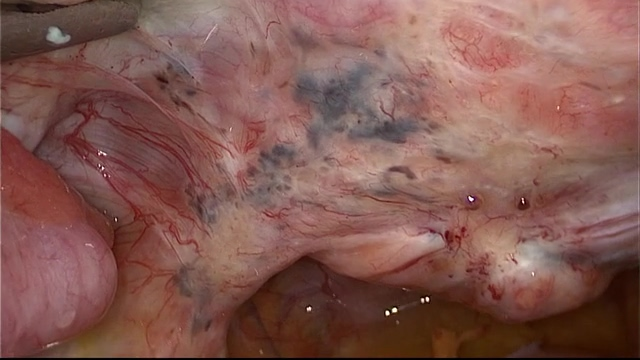

In [11]:
import os
from PIL import Image

img_path = os.path.join(
    "../data/external/glenda_enid/endometriosis",
    "enid_0.jpg"
)

img = Image.open(img_path).convert("RGB")

img

In [12]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(img).unsqueeze(0)

input_tensor = input_tensor.to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [13]:
output = model(input_tensor)

pred_class = output.argmax(dim=1)

model.zero_grad()

output[0, pred_class].backward()

print("Predicted Class:", pred_class.item())

Predicted Class: 0


In [14]:
pooled_gradients = torch.mean(
    gradients,
    dim=[0, 2, 3]
)

activation_map = activations[0]

for i in range(activation_map.shape[0]):
    activation_map[i] *= pooled_gradients[i]

heatmap = activation_map.mean(dim=0)

heatmap = heatmap.detach().cpu().numpy()

heatmap = np.maximum(heatmap, 0)

heatmap /= heatmap.max()

print(heatmap.shape)

(7, 7)


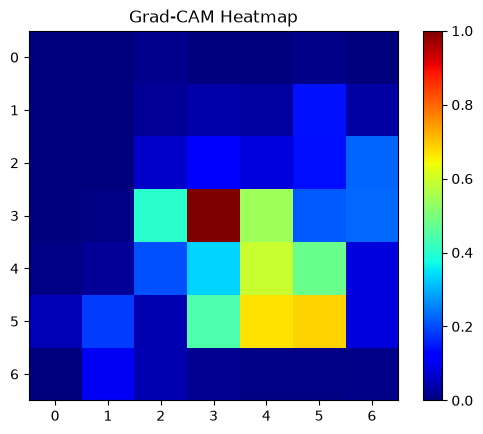

In [21]:
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.savefig(
    "../docs/figures/glenda_gradcam_heatmap.png"
)
plt.show()

In [17]:
import cv2

print(cv2.__version__)

4.13.0


In [18]:
import cv2

In [19]:
img_cv = cv2.imread(img_path)

img_cv = cv2.cvtColor(
    img_cv,
    cv2.COLOR_BGR2RGB
)

heatmap_resized = cv2.resize(
    heatmap,
    (img_cv.shape[1], img_cv.shape[0])
)

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

superimposed = (
    0.6 * img_cv +
    0.4 * heatmap_color
)

superimposed = np.uint8(superimposed)

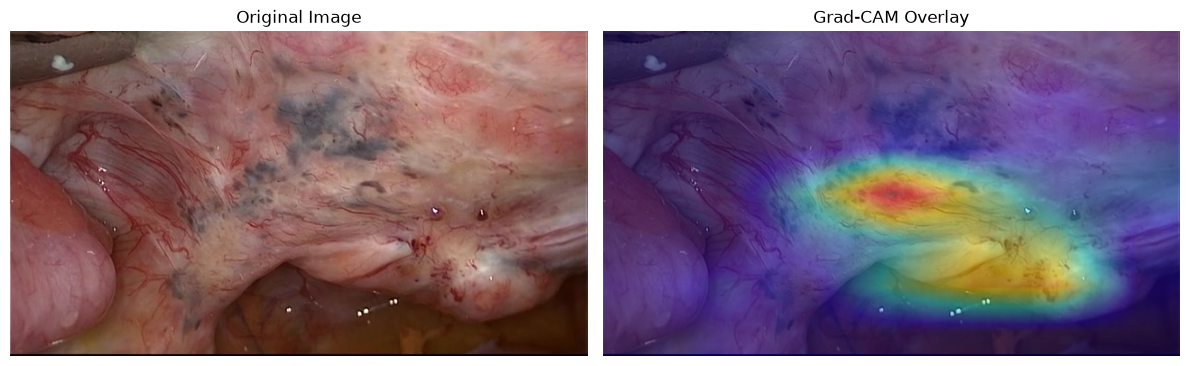

In [20]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_cv)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(superimposed)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/figures/glenda_gradcam_example.png"
)

plt.show()